# Quantium Virtual Internship - Retail Strategy and Analytics
# Task 2: Experimentación y evaluación de una prueba de tienda (Python)

**Autor:** Andrés Giraldo Ramírez (Midas)
**Rol:** Data Analyst

Este notebook replica en Python el análisis solicitado en la Task 2 del programa de Quantium
(originalmente resuelto en R con `data.table` y `ggplot2`).

**Objetivo:** Julia (Category Manager) nos pidió evaluar el desempeño de una prueba de tienda
realizada en las tiendas **77, 86 y 88**. Para ello:

1. Seleccionamos tiendas de **control** similares a cada tienda de prueba (antes del periodo de prueba).
2. Comparamos el desempeño de prueba vs. control **durante** el periodo de prueba (feb–abr 2019).
3. Determinamos si hay una diferencia estadísticamente significativa en ventas y clientes.


## 0. Librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None


## 1. Carga de datos

Cargamos `QVI_data.csv`, la salida a nivel transaccional de la Task 1
(ya limpia: outliers removidos, columnas de `PACK_SIZE`, `BRAND`, `LIFESTAGE`, `PREMIUM_CUSTOMER` derivadas).

In [7]:
data = pd.read_csv("QVI_data_2.csv")
data['DATE'] = pd.to_datetime(data['DATE'])

print(data.shape)
data.head()


(264834, 12)


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


## 2. Selección de tiendas de control

El cliente seleccionó las tiendas **77, 86 y 88** como tiendas de prueba. Necesitamos tiendas de
control que sean similares a las de prueba **antes** del periodo de prueba (feb 2019), en términos de:

- Ingresos de ventas mensuales
- Número mensual de clientes
- Número de transacciones por cliente mensual

### 2.1 Columna YEARMONTH y métricas mensuales por tienda

In [8]:
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

def compute_measures(df):
    """Calcula, por tienda y mes: ventas totales, nº clientes, transacciones por cliente,
    chips por transacción y precio promedio por unidad."""
    grp = df.groupby(['STORE_NBR', 'YEARMONTH'])
    out = grp.apply(lambda g: pd.Series({
        'totSales': g['TOT_SALES'].sum(),
        'nCustomers': g['LYLTY_CARD_NBR'].nunique(),
        'nTxnPerCust': g['TXN_ID'].nunique() / g['LYLTY_CARD_NBR'].nunique(),
        'nChipsPerTxn': g['PROD_QTY'].sum() / g['TXN_ID'].nunique(),
        'avgPricePerUnit': g['TOT_SALES'].sum() / g['PROD_QTY'].sum(),
    }), include_groups=False).reset_index()
    return out.sort_values(['STORE_NBR', 'YEARMONTH']).reset_index(drop=True)

measureOverTime = compute_measures(data)
measureOverTime.head(12)


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49.0,1.061224,1.192308,3.337097
1,1,201808,176.1,42.0,1.023810,1.255814,3.261111
2,1,201809,278.8,59.0,1.050847,1.209677,3.717333
3,1,201810,188.1,44.0,1.022727,1.288889,3.243103
4,1,201811,192.6,46.0,1.021739,1.212766,3.378947
5,1,201812,189.6,42.0,1.119048,1.212766,3.326316
6,1,201901,154.8,35.0,1.028571,1.166667,3.685714
7,1,201902,225.4,52.0,1.057692,1.181818,3.467692
8,1,201903,192.9,45.0,1.088889,1.183673,3.325862
9,1,201904,192.9,42.0,1.023810,1.325581,3.384211


### 2.2 Filtrar tiendas con periodo de observación completo (12 meses) y periodo pre-trial

In [9]:
storesWithFullObs = (
    measureOverTime.groupby('STORE_NBR')['YEARMONTH'].count()
    .loc[lambda s: s == 12]
    .index
)
print(f"Tiendas con observación completa: {len(storesWithFullObs)}")

preTrialMeasures = measureOverTime[
    (measureOverTime['YEARMONTH'] < 201902) &
    (measureOverTime['STORE_NBR'].isin(storesWithFullObs))
].copy()

preTrialMeasures.shape


Tiendas con observación completa: 260


(1820, 7)

### 2.3 Funciones de similitud: correlación y distancia de magnitud

- **Correlación de Pearson**: qué tan parecida es la *tendencia* de la tienda candidata a la tienda de prueba.
- **Distancia de magnitud estandarizada**: qué tan parecido es el *nivel absoluto* de la métrica,
  normalizado entre 0 y 1: `1 - (dist - min_dist) / (max_dist - min_dist)`.

In [10]:
def calculate_correlation(inputTable: pd.DataFrame, metricCol: str, storeComparison: int) -> pd.DataFrame:
    """Calcula la correlación de Pearson entre la tienda de prueba y cada tienda candidata,
    para una métrica dada (equivalente a calculateCorrelation() del script en R)."""
    storeNumbers = inputTable['STORE_NBR'].unique()
    trial_series = inputTable[inputTable['STORE_NBR'] == storeComparison].set_index('YEARMONTH')[metricCol]

    rows = []
    for store in storeNumbers:
        other_series = inputTable[inputTable['STORE_NBR'] == store].set_index('YEARMONTH')[metricCol]
        joined = pd.concat([trial_series, other_series], axis=1, join='inner')
        if len(joined) > 1 and joined.iloc[:, 0].std() > 0 and joined.iloc[:, 1].std() > 0:
            corr = joined.iloc[:, 0].corr(joined.iloc[:, 1])
        else:
            corr = np.nan
        rows.append({'Store1': storeComparison, 'Store2': store, 'corr_measure': corr})

    return pd.DataFrame(rows)


def calculate_magnitude_distance(inputTable: pd.DataFrame, metricCol: str, storeComparison: int) -> pd.DataFrame:
    """Calcula una distancia de magnitud estandarizada (0 a 1) entre la tienda de prueba
    y cada tienda candidata, para una métrica dada (equivalente a calculateMagnitudeDistance() en R)."""
    storeNumbers = inputTable['STORE_NBR'].unique()
    trial_series = inputTable[inputTable['STORE_NBR'] == storeComparison].set_index('YEARMONTH')[metricCol]

    rows = []
    for store in storeNumbers:
        other_series = inputTable[inputTable['STORE_NBR'] == store].set_index('YEARMONTH')[metricCol]
        joined = pd.concat([trial_series, other_series], axis=1, join='inner')
        joined.columns = ['trial', 'other']
        for yearmonth, r in joined.iterrows():
            rows.append({
                'Store1': storeComparison, 'Store2': store, 'YEARMONTH': yearmonth,
                'measure': abs(r['trial'] - r['other'])
            })

    dist = pd.DataFrame(rows)
    minmax = dist.groupby(['Store1', 'YEARMONTH'])['measure'].agg(minDist='min', maxDist='max').reset_index()
    dist = dist.merge(minmax, on=['Store1', 'YEARMONTH'])

    denom = (dist['maxDist'] - dist['minDist']).replace(0, np.nan)
    dist['magnitudeMeasure'] = 1 - (dist['measure'] - dist['minDist']) / denom
    dist['magnitudeMeasure'] = dist['magnitudeMeasure'].fillna(1.0)  # min == max -> distancia perfecta

    return (
        dist.groupby(['Store1', 'Store2'])['magnitudeMeasure']
        .mean().reset_index()
        .rename(columns={'magnitudeMeasure': 'mag_measure'})
    )


### 2.4 Función de selección de tienda de control

Combinamos correlación y magnitud (promedio simple, `corr_weight = 0.5`) para ventas y clientes,
y luego promediamos ambos drivers para obtener el `finalControlScore`. La tienda candidata con el
score más alto (excluyendo la propia tienda de prueba) se selecciona como control.

In [11]:
def select_control_store(preTrialMeasures: pd.DataFrame, trial_store: int, corr_weight: float = 0.5):
    corr_nSales = calculate_correlation(preTrialMeasures, 'totSales', trial_store)
    corr_nCustomers = calculate_correlation(preTrialMeasures, 'nCustomers', trial_store)
    magnitude_nSales = calculate_magnitude_distance(preTrialMeasures, 'totSales', trial_store)
    magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures, 'nCustomers', trial_store)

    score_nSales = corr_nSales.merge(magnitude_nSales, on=['Store1', 'Store2'])
    score_nSales['scoreNSales'] = corr_weight * score_nSales['corr_measure'] + (1 - corr_weight) * score_nSales['mag_measure']

    score_nCustomers = corr_nCustomers.merge(magnitude_nCustomers, on=['Store1', 'Store2'])
    score_nCustomers['scoreNCust'] = corr_weight * score_nCustomers['corr_measure'] + (1 - corr_weight) * score_nCustomers['mag_measure']

    score_Control = score_nSales[['Store1', 'Store2', 'scoreNSales']].merge(
        score_nCustomers[['Store1', 'Store2', 'scoreNCust']], on=['Store1', 'Store2']
    )
    score_Control['finalControlScore'] = score_Control['scoreNSales'] * 0.5 + score_Control['scoreNCust'] * 0.5

    ranked = score_Control[score_Control['Store2'] != trial_store].sort_values('finalControlScore', ascending=False)
    control_store = int(ranked.iloc[0]['Store2'])
    return control_store, score_Control


### 2.5 Aplicar a la tienda de prueba 77

In [12]:
trial_store = 77
control_store, score_Control_77 = select_control_store(preTrialMeasures, trial_store)
print(f"Tienda de control seleccionada para la tienda de prueba {trial_store}: {control_store}")
score_Control_77.sort_values('finalControlScore', ascending=False).head()


Tienda de control seleccionada para la tienda de prueba 77: 233


,Store1,Store2,scoreNSales,scoreNCust,finalControlScore
72,77,77,1.000000,1.000000,1.000000
221,77,233,0.944520,0.991566,0.968043
38,77,41,0.874186,0.909429,0.891808
15,77,17,0.861678,0.854902,0.858290
241,77,254,0.749940,0.926670,0.838305


### 2.6 Chequeo visual: ventas totales pre-trial (tienda 77 vs control vs otras)

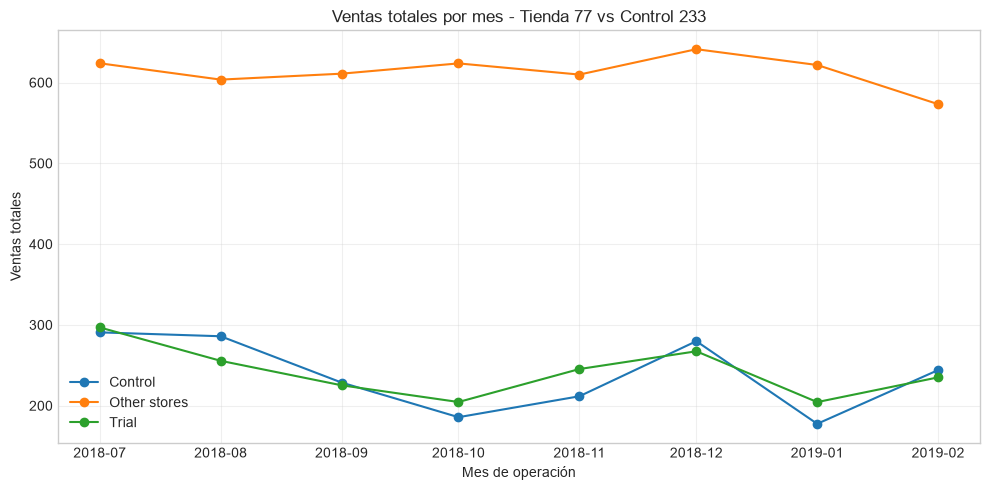

In [13]:
def plot_pre_trial(measureOverTime, trial_store, control_store, metric, ylabel, title, ymonth_cutoff=201903):
    df = measureOverTime.copy()
    df['Store_type'] = np.where(df['STORE_NBR'] == trial_store, 'Trial',
                          np.where(df['STORE_NBR'] == control_store, 'Control', 'Other stores'))
    agg = df.groupby(['YEARMONTH', 'Store_type'])[metric].mean().reset_index()
    agg['TransactionMonth'] = pd.to_datetime(agg['YEARMONTH'].astype(str), format='%Y%m')
    agg = agg[agg['YEARMONTH'] < ymonth_cutoff]

    fig, ax = plt.subplots()
    for store_type, g in agg.groupby('Store_type'):
        g = g.sort_values('TransactionMonth')
        ax.plot(g['TransactionMonth'], g[metric], marker='o', label=store_type)
    ax.set_xlabel('Mes de operación')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend()
    plt.tight_layout()
    plt.show()
    return agg

_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'totSales',
                    'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')


### 2.7 Chequeo visual: número de clientes pre-trial

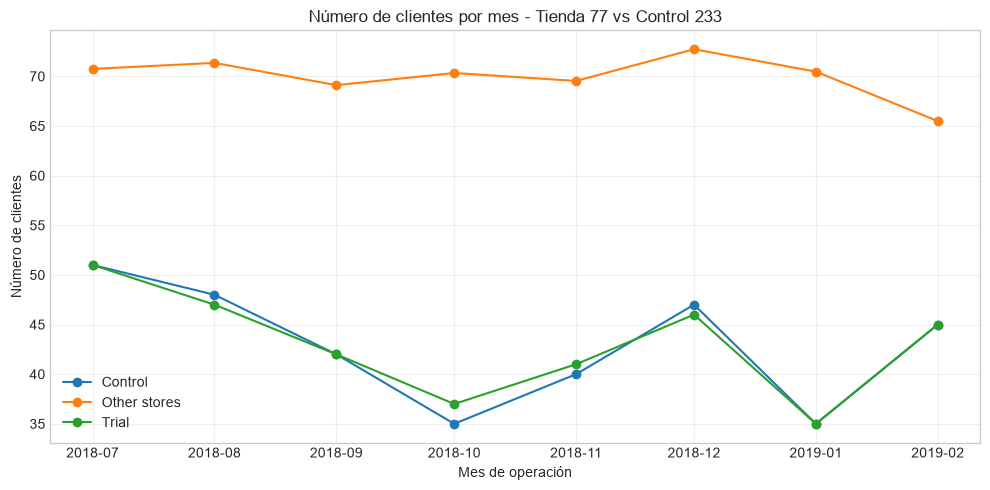

In [14]:
_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'nCustomers',
                    'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')


## 3. Evaluación del trial - Tienda 77

El periodo de prueba va de **febrero a abril de 2019**. Escalamos las ventas de la tienda de
control al nivel de la tienda de prueba (usando el periodo pre-trial) para poder comparar de
forma justa, y luego calculamos el porcentaje de diferencia y su significancia estadística (t-test,
7 grados de libertad porque hay 8 meses pre-trial).

In [15]:
def assess_trial(measureOverTime, preTrialMeasures, trial_store, control_store, metric='totSales'):
    """Escala la métrica de la tienda control, calcula % de diferencia vs trial, stdDev y t-values."""
    scalingFactor = (
        preTrialMeasures.loc[(preTrialMeasures.STORE_NBR == trial_store) & (preTrialMeasures.YEARMONTH < 201902), metric].sum()
        / preTrialMeasures.loc[(preTrialMeasures.STORE_NBR == control_store) & (preTrialMeasures.YEARMONTH < 201902), metric].sum()
    )

    control = measureOverTime[measureOverTime.STORE_NBR == control_store][['YEARMONTH', metric]].copy()
    control['controlMetric'] = control[metric] * scalingFactor

    trial = measureOverTime[measureOverTime.STORE_NBR == trial_store][['YEARMONTH', metric]].copy()
    trial = trial.rename(columns={metric: 'trialMetric'})

    percentageDiff = control[['YEARMONTH', 'controlMetric']].merge(trial, on='YEARMONTH')
    percentageDiff['percentageDiff'] = abs(percentageDiff['controlMetric'] - percentageDiff['trialMetric']) / percentageDiff['controlMetric']

    stdDev = percentageDiff.loc[percentageDiff.YEARMONTH < 201902, 'percentageDiff'].std(ddof=1)
    degreesOfFreedom = 7
    percentageDiff['tValue'] = percentageDiff['percentageDiff'] / stdDev
    percentageDiff['TransactionMonth'] = pd.to_datetime(percentageDiff['YEARMONTH'].astype(str), format='%Y%m')

    return percentageDiff, stdDev, degreesOfFreedom, scalingFactor


percentageDiff_77, stdDev_77, dof_77, scaling_77 = assess_trial(measureOverTime, preTrialMeasures, trial_store, control_store, 'totSales')

crit_t = stats.t.ppf(0.95, dof_77)
print(f"Valor crítico t (percentil 95, {dof_77} gl): {crit_t:.3f}")
print()
trial_months = percentageDiff_77[(percentageDiff_77.YEARMONTH >= 201902) & (percentageDiff_77.YEARMONTH <= 201904)]
trial_months[['YEARMONTH', 'percentageDiff', 'tValue']].assign(
    significativo=lambda d: d['tValue'] > crit_t
)


Valor crítico t (percentil 95, 7 gl): 1.895



,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.059107,1.183534,False
8,201903,0.366521,7.339116,True
9,201904,0.623080,12.476373,True


### 3.1 Visualización: ventas de la tienda de prueba vs. banda de confianza de la tienda de control (5%-95%)

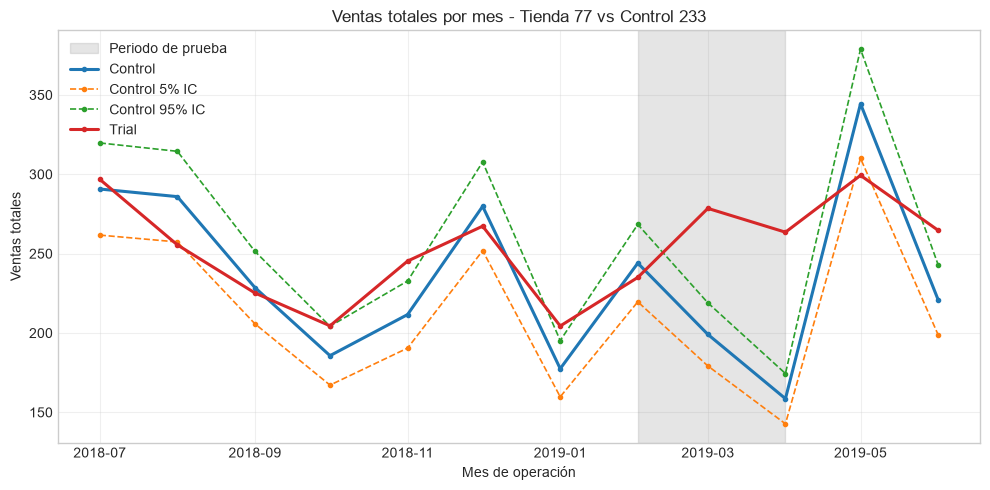

In [16]:
def plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev, metric, ylabel, title):
    df = measureOverTime.copy()
    df['Store_type'] = np.where(df['STORE_NBR'] == trial_store, 'Trial',
                          np.where(df['STORE_NBR'] == control_store, 'Control', 'Other stores'))
    base = df[df['Store_type'].isin(['Trial', 'Control'])][['YEARMONTH', 'Store_type', metric]].copy()
    base['TransactionMonth'] = pd.to_datetime(base['YEARMONTH'].astype(str), format='%Y%m')

    ctrl95 = base[base.Store_type == 'Control'].copy()
    ctrl95[metric] = ctrl95[metric] * (1 + stdDev * 2)
    ctrl95['Store_type'] = 'Control 95% IC'

    ctrl5 = base[base.Store_type == 'Control'].copy()
    ctrl5[metric] = ctrl5[metric] * (1 - stdDev * 2)
    ctrl5['Store_type'] = 'Control 5% IC'

    trialAssessment = pd.concat([base, ctrl95, ctrl5], ignore_index=True)

    fig, ax = plt.subplots()
    trial_start = pd.to_datetime('201902', format='%Y%m')
    trial_end = pd.to_datetime('201904', format='%Y%m')
    ax.axvspan(trial_start, trial_end, color='grey', alpha=0.2, label='Periodo de prueba')

    styles = {'Trial': ('-', 2.2), 'Control': ('-', 2.2), 'Control 95% IC': ('--', 1.2), 'Control 5% IC': ('--', 1.2)}
    for store_type, g in trialAssessment.groupby('Store_type'):
        g = g.sort_values('TransactionMonth')
        ls, lw = styles.get(store_type, ('-', 1))
        ax.plot(g['TransactionMonth'], g[metric], linestyle=ls, linewidth=lw, marker='o', markersize=3, label=store_type)

    ax.set_xlabel('Mes de operación')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend()
    plt.tight_layout()
    plt.show()
    return trialAssessment

_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_77, 'totSales',
                           'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')


### 3.2 Evaluación del trial para número de clientes (tienda 77)

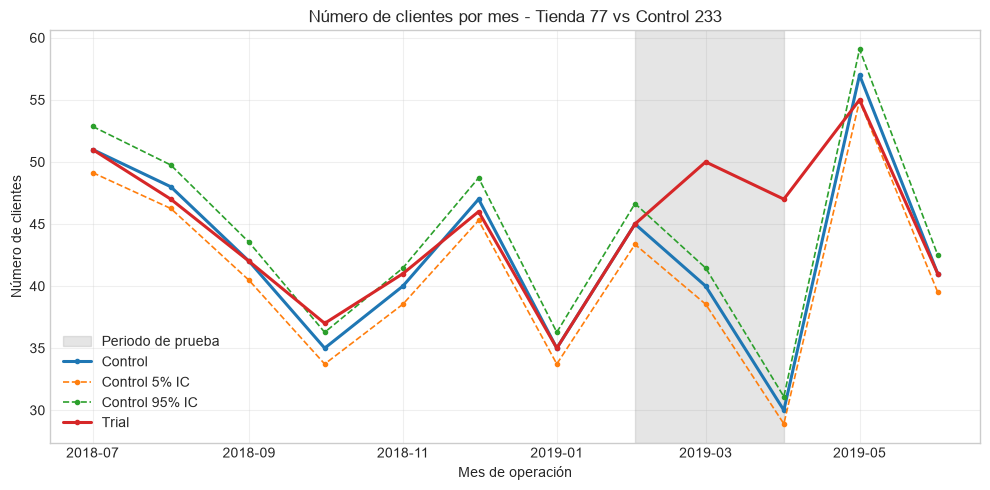

,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.003344,0.183352,False
8,201903,0.245819,13.476388,True
9,201904,0.561427,30.778725,True


In [17]:
percentageDiff_77_cust, stdDev_77_cust, dof_77_cust, scaling_77_cust = assess_trial(
    measureOverTime, preTrialMeasures, trial_store, control_store, 'nCustomers'
)

_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_77_cust, 'nCustomers',
                           'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')

crit_t_cust = stats.t.ppf(0.95, dof_77_cust)
trial_months_cust = percentageDiff_77_cust[(percentageDiff_77_cust.YEARMONTH >= 201902) & (percentageDiff_77_cust.YEARMONTH <= 201904)]
trial_months_cust[['YEARMONTH', 'percentageDiff', 'tValue']].assign(
    significativo=lambda d: d['tValue'] > crit_t_cust
)


**Conclusión tienda 77:** el desempeño de la tienda de prueba 77 es significativamente distinto
al de su tienda de control durante el periodo de prueba, ya que sus ventas quedan fuera de la banda
de confianza 5%-95% de la tienda de control en al menos dos de los tres meses de prueba.

## 4. Repetimos el análisis para la tienda de prueba 86

In [18]:
trial_store = 86
control_store, score_Control_86 = select_control_store(preTrialMeasures, trial_store)
print(f"Tienda de control seleccionada para la tienda de prueba {trial_store}: {control_store}")


Tienda de control seleccionada para la tienda de prueba 86: 155


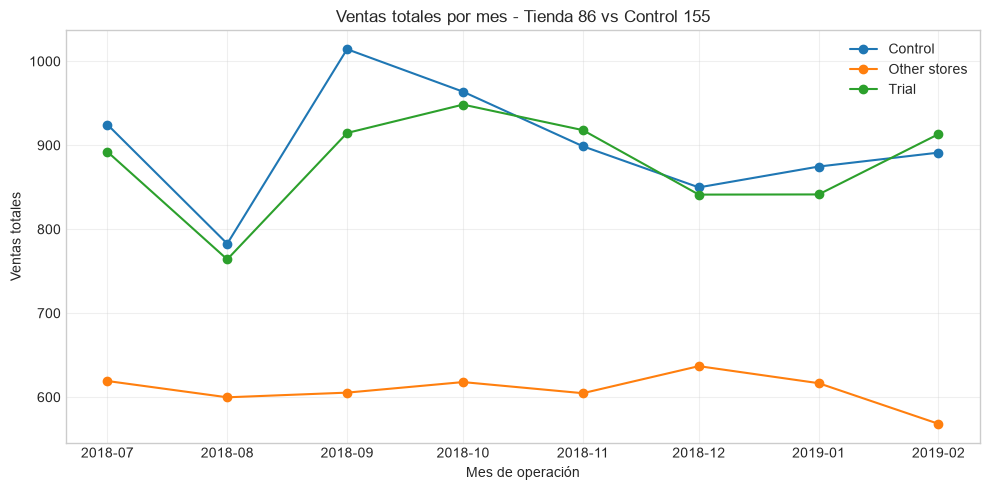

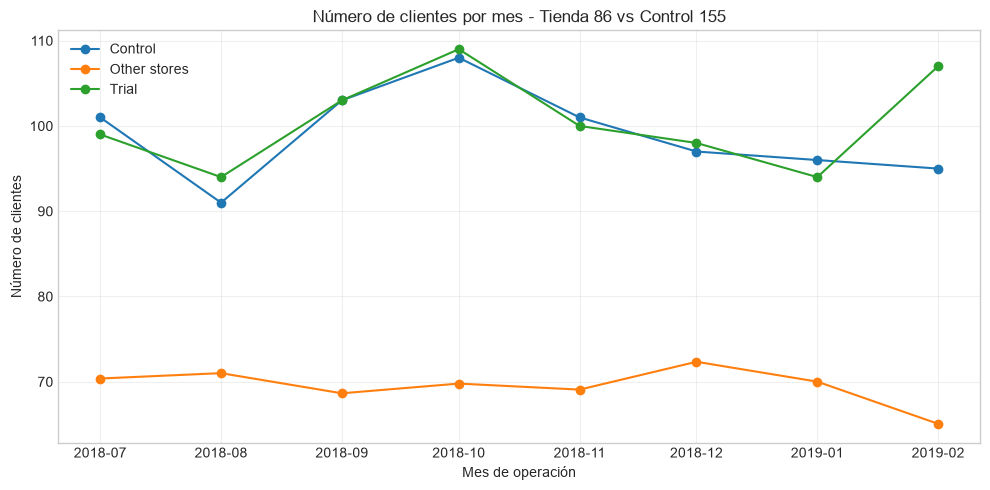

In [19]:
_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'totSales',
                    'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')
_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'nCustomers',
                    'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')


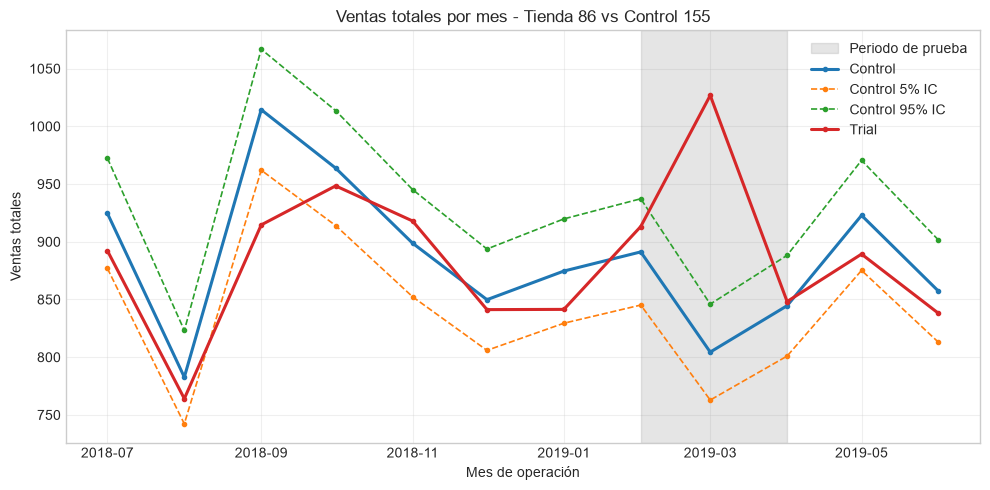

,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.056306,2.179542,True
8,201903,0.315870,12.226922,True
9,201904,0.035253,1.364580,False


In [20]:
percentageDiff_86, stdDev_86, dof_86, scaling_86 = assess_trial(measureOverTime, preTrialMeasures, trial_store, control_store, 'totSales')
_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_86, 'totSales',
                           'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')

crit_t = stats.t.ppf(0.95, dof_86)
trial_months = percentageDiff_86[(percentageDiff_86.YEARMONTH >= 201902) & (percentageDiff_86.YEARMONTH <= 201904)]
trial_months[['YEARMONTH', 'percentageDiff', 'tValue']].assign(significativo=lambda d: d['tValue'] > crit_t)


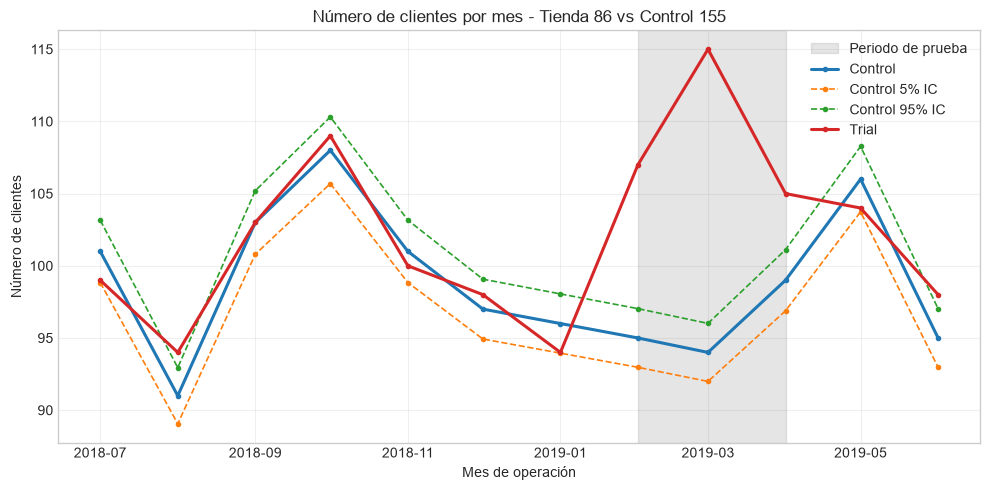

,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.126316,11.819082,True
8,201903,0.223404,20.903430,True
9,201904,0.060606,5.670772,True


In [21]:
percentageDiff_86_cust, stdDev_86_cust, dof_86_cust, scaling_86_cust = assess_trial(
    measureOverTime, preTrialMeasures, trial_store, control_store, 'nCustomers'
)
_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_86_cust, 'nCustomers',
                           'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')

crit_t_cust = stats.t.ppf(0.95, dof_86_cust)
trial_months_cust = percentageDiff_86_cust[(percentageDiff_86_cust.YEARMONTH >= 201902) & (percentageDiff_86_cust.YEARMONTH <= 201904)]
trial_months_cust[['YEARMONTH', 'percentageDiff', 'tValue']].assign(significativo=lambda d: d['tValue'] > crit_t_cust)


**Conclusión tienda 86:** las ventas totales **no** son significativamente distintas entre la
tienda de prueba y su control (quedan dentro de la banda 5%-95%), pero el **número de clientes sí es
significativamente mayor** en los tres meses del trial. Esto sugiere que el trial atrajo más clientes
en la tienda 86, pero no se tradujo en un aumento significativo de ventas — vale la pena preguntar al
Category Manager si hubo promociones o precios más bajos en esta tienda durante el periodo de prueba.

## 5. Repetimos el análisis para la tienda de prueba 88

In [22]:
trial_store = 88
control_store, score_Control_88 = select_control_store(preTrialMeasures, trial_store)
print(f"Tienda de control seleccionada para la tienda de prueba {trial_store}: {control_store}")


Tienda de control seleccionada para la tienda de prueba 88: 237


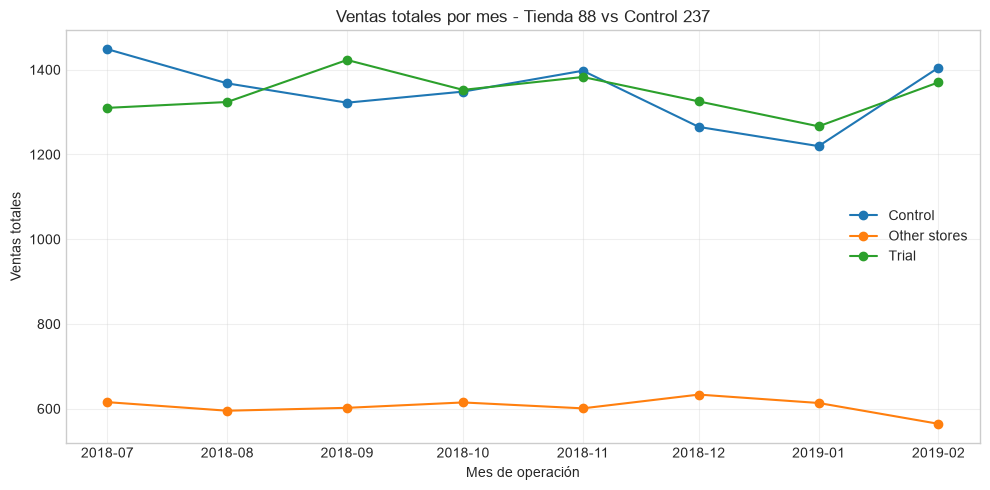

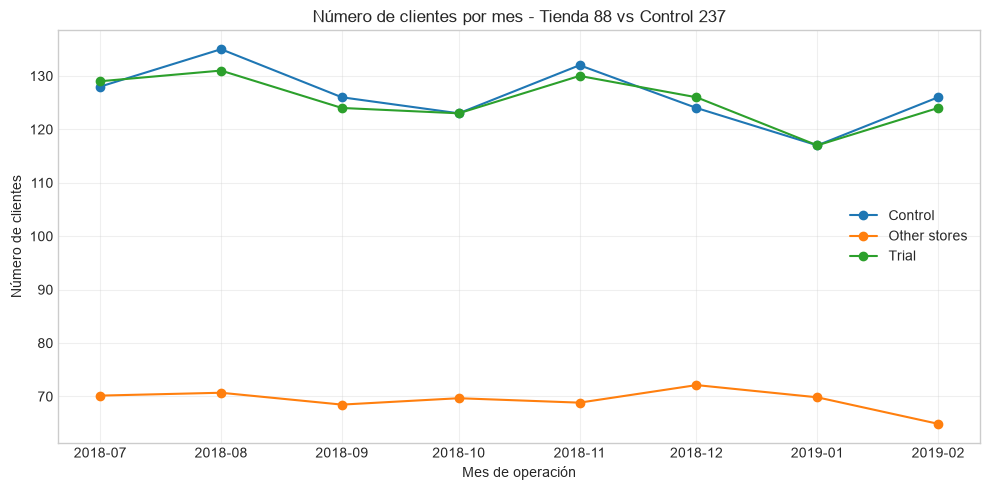

In [23]:
_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'totSales',
                    'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')
_ = plot_pre_trial(measureOverTime, trial_store, control_store, 'nCustomers',
                    'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')


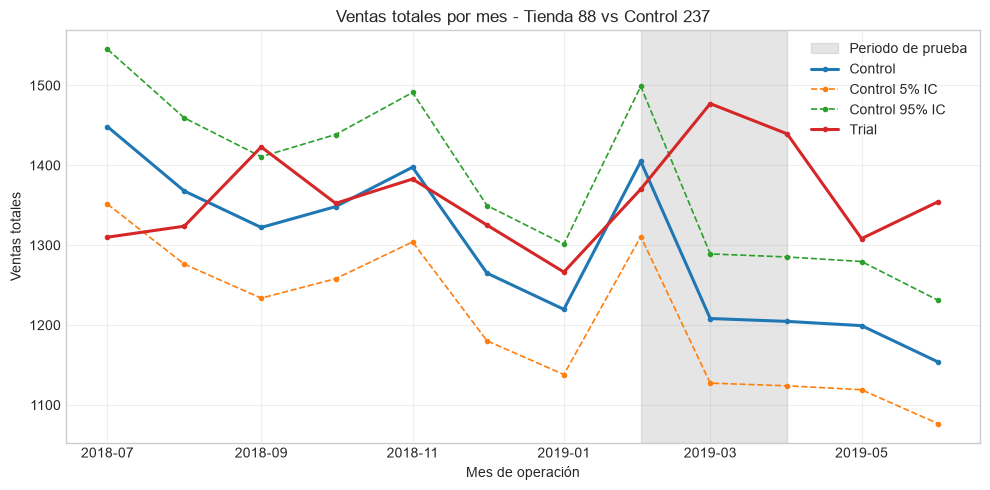

,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.026147,0.781270,False
8,201903,0.220743,6.595668,True
9,201904,0.193060,5.768527,True


In [24]:
percentageDiff_88, stdDev_88, dof_88, scaling_88 = assess_trial(measureOverTime, preTrialMeasures, trial_store, control_store, 'totSales')
_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_88, 'totSales',
                           'Ventas totales', f'Ventas totales por mes - Tienda {trial_store} vs Control {control_store}')

crit_t = stats.t.ppf(0.95, dof_88)
trial_months = percentageDiff_88[(percentageDiff_88.YEARMONTH >= 201902) & (percentageDiff_88.YEARMONTH <= 201904)]
trial_months[['YEARMONTH', 'percentageDiff', 'tValue']].assign(significativo=lambda d: d['tValue'] > crit_t)


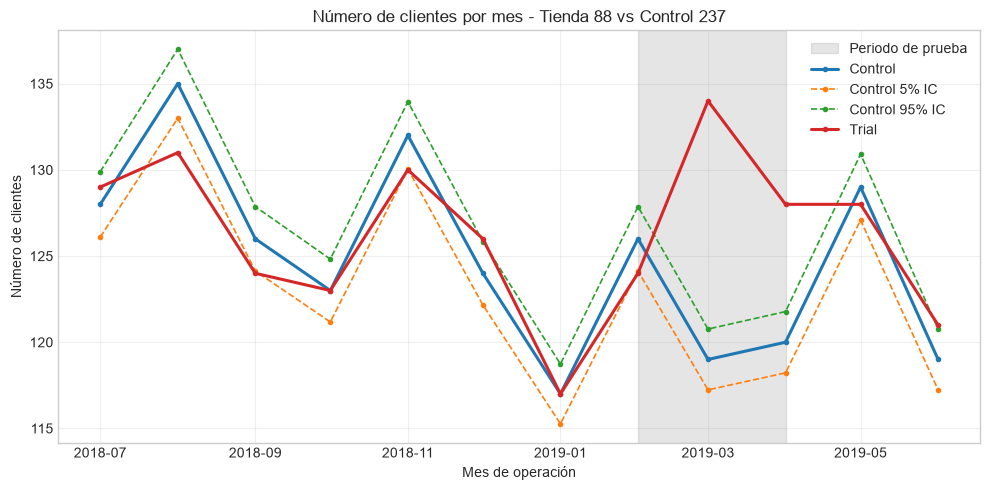

,YEARMONTH,percentageDiff,tValue,significativo
7,201902,0.010281,1.387456,False
8,201903,0.132448,17.873693,True
9,201904,0.072727,9.814423,True


In [25]:
percentageDiff_88_cust, stdDev_88_cust, dof_88_cust, scaling_88_cust = assess_trial(
    measureOverTime, preTrialMeasures, trial_store, control_store, 'nCustomers'
)
_ = plot_trial_assessment(measureOverTime, trial_store, control_store, stdDev_88_cust, 'nCustomers',
                           'Número de clientes', f'Número de clientes por mes - Tienda {trial_store} vs Control {control_store}')

crit_t_cust = stats.t.ppf(0.95, dof_88_cust)
trial_months_cust = percentageDiff_88_cust[(percentageDiff_88_cust.YEARMONTH >= 201902) & (percentageDiff_88_cust.YEARMONTH <= 201904)]
trial_months_cust[['YEARMONTH', 'percentageDiff', 'tValue']].assign(significativo=lambda d: d['tValue'] > crit_t_cust)


**Conclusión tienda 88:** tanto las ventas totales como el número de clientes son
significativamente mayores en la tienda de prueba frente a su control durante al menos dos de los
tres meses del trial, indicando un efecto positivo claro.

## 6. Conclusión general

Se identificaron las siguientes tiendas de control:

| Tienda de prueba | Tienda de control |
|---|---|
| 77 | 233 |
| 86 | 155 |
| 88 | 237 |

**Hallazgos:**
- **Tienda 77:** incremento significativo en ventas totales durante el trial.
- **Tienda 86:** sin incremento significativo en ventas, pero sí en número de clientes — posible
  indicio de precios promocionales más bajos que atrajeron más clientes sin subir el ticket total.
  Se recomienda validar con el Category Manager si hubo una implementación distinta del trial en esta tienda.
- **Tienda 88:** incremento significativo tanto en ventas como en número de clientes.

**En conjunto**, el trial muestra evidencia de un incremento significativo en ventas en 2 de las 3
tiendas evaluadas, y un efecto positivo consistente sobre el número de clientes en las 3 tiendas.
Esto respalda continuar con el rollout de la iniciativa, sujeto a revisar qué ocurrió puntualmente
en la tienda 86.
